In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import geopandas as gpd
import os
import rasterio
import contextily as cx
import pyproj
import requests
import json

from shapely.geometry import Point
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point, LineString

from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from matplotlib.colors import LightSource
from rasterio.merge import merge
from rasterio.transform import array_bounds

In [2]:
gravity_path = "../../data/gravity/raw_data/gps_data/gravity_05_27_2026.csv"
poi_path = "../../data/GPR/raw_data/GPS_Emlid/group2_onyx_mine.csv"

gravity_df = pd.read_csv(gravity_path)
poi_df = pd.read_csv(poi_path)

gravity_gps = gravity_df[["Name", "Longitude", "Latitude", "Ellipsoidal height"]].copy()
gravity_gps = gravity_gps.rename(columns={
    "Name": "station",
    "Ellipsoidal height": "elevation_m"
})

poi_gps = poi_df[["Name", "Longitude", "Latitude", "Elevation", "Ellipsoidal height"]].copy()
poi_gps = poi_gps.rename(columns={
    "Name": "point_name",
    "Elevation": "elevation_m",
    "Ellipsoidal height": "ellipsoidal_height_m"
})

gravity_gdf = gpd.GeoDataFrame(
    gravity_gps,
    geometry=gpd.points_from_xy(gravity_gps["Longitude"], gravity_gps["Latitude"]),
    crs="EPSG:4326"
)

poi_gdf = gpd.GeoDataFrame(
    poi_gps,
    geometry=gpd.points_from_xy(poi_gps["Longitude"], poi_gps["Latitude"]),
    crs="EPSG:4326"
)

In [3]:
gpr_folder_gopher = Path("../../data/GPR/raw_data/Gopher/")
gpr_folder_moose = Path("../../data/GPR/raw_data/Moose/")

gps_extensions = [".csv", ".txt", ".gps", ".gpx", ".kml", ".cor", ".xyz"]

gpr_gps_candidates = []

for folder in [gpr_folder_gopher, gpr_folder_moose]:
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in gps_extensions:
            gpr_gps_candidates.append(file)

print("Possible GPR GPS files found:", len(gpr_gps_candidates))
for file in gpr_gps_candidates:
    print(file)

Possible GPR GPS files found: 12
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0005.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0006.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0007.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0008.cor


In [4]:
gpr_dfs = []

for file in gpr_gps_candidates:
    temp = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=[
            "trace",
            "date",
            "time",
            "latitude",
            "lat_dir",
            "longitude",
            "lon_dir",
            "elevation_m",
            "elevation_unit",
            "quality"
        ]
    )
    
    temp["source_file"] = file.name
    
    if "gopher" in str(file).lower():
        temp["gpr_device"] = "Gopher"
    else:
        temp["gpr_device"] = "Moose"
    
    temp["line_name"] = file.stem
    gpr_dfs.append(temp)

gpr_df = pd.concat(gpr_dfs, ignore_index=True)

gpr_df["latitude"] = pd.to_numeric(gpr_df["latitude"], errors="coerce")
gpr_df["longitude"] = pd.to_numeric(gpr_df["longitude"], errors="coerce")
gpr_df["elevation_m"] = pd.to_numeric(gpr_df["elevation_m"], errors="coerce")

gpr_df.loc[gpr_df["lat_dir"].str.upper() == "S", "latitude"] *= -1
gpr_df.loc[gpr_df["lon_dir"].str.upper() == "W", "longitude"] *= -1

gpr_df = gpr_df.dropna(subset=["latitude", "longitude"]).copy()

gpr_points_gdf = gpd.GeoDataFrame(
    gpr_df,
    geometry=gpd.points_from_xy(gpr_df["longitude"], gpr_df["latitude"]),
    crs="EPSG:4326"
)

gpr_lines = []

for line_name, group in gpr_points_gdf.groupby("line_name"):
    group = group.sort_values("trace")
    
    if len(group) >= 2:
        gpr_lines.append({
            "line_name": line_name,
            "gpr_device": group["gpr_device"].iloc[0],
            "n_points": len(group),
            "geometry": LineString(group.geometry.tolist())
        })

gpr_lines_gdf = gpd.GeoDataFrame(gpr_lines, crs="EPSG:4326")

display(gpr_lines_gdf[["line_name", "gpr_device", "n_points"]])

C:\Users\molly\AppData\Local\Temp\ipykernel_26956\4053105417.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gpr_df = pd.concat(gpr_dfs, ignore_index=True)


,line_name,gpr_device,n_points
0,GPR_group2_2026_05_21_2026-05-25_0001,Moose,8
1,GPR_group2_2026_05_21_2026-05-25_0002,Moose,162
2,GPR_group2_2026_05_21_2026-05-25_0003,Moose,138
3,GPR_group2_2026_05_21_2026-05-25_0004,Moose,460
4,GPR_group2_2026_05_21_2026-05-25_0005,Moose,466
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
7,GPR_group2_2026_05_25_gopher_2026-05-25_0001,Gopher,5
8,GPR_group2_2026_05_25_gopher_2026-05-25_0002,Gopher,2
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113


In [5]:
gravity_3857 = gravity_gdf.to_crs(epsg=3857)
poi_3857 = poi_gdf.to_crs(epsg=3857)
gpr_lines_3857 = gpr_lines_gdf.to_crs(epsg=3857)
gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

In [6]:
selected_gpr_lines = gpr_lines_3857[
    (
        (gpr_lines_3857["gpr_device"] == "Gopher") &
        (gpr_lines_3857["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_3857["gpr_device"] == "Moose") &
        (gpr_lines_3857["line_name"].str.endswith(("0007", "0008")))
    )
].copy()

display(selected_gpr_lines[["line_name", "gpr_device", "n_points"]])

,line_name,gpr_device,n_points
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113
10,GPR_group2_2026_05_25_gopher_2026-05-25_0004,Gopher,65


In [7]:
anomaly_df = pd.DataFrame({
    "anomaly_id": [
        "G03-A", "G03-B", "G03-C",
        "G04-A", "G04-B",
        "M07-A",
        "M08-A", "M08-B"
    ],

    "line": [
        "Gopher 03", "Gopher 03", "Gopher 03",
        "Gopher 04", "Gopher 04",
        "Moose 07",
        "Moose 08", "Moose 08"
    ],

    "frequency_MHz": [
        600, 600, 600,
        600, 600,
        300,
        300, 300
    ],

    "easting": [
        344405.8, 344414.1, 344421.0,
        344417.2, 344414.2,
        344422.0,
        344404.5, 344414.0
    ],

    "northing": [
        4482540.1, 4482521.8, 4482499.8,
        4482507.0, 4482520.6,
        4482496.4,
        4482538.4, 4482517.1
    ],

    "twt_ns": [
        28.8, 15.8, 14.6,
        36.4, 23.9,
        128.3,
        40.8, 22.8
    ]
})

In [8]:
velocity = 0.10  # m/ns

anomaly_df["depth_m"] = (
    anomaly_df["twt_ns"] * velocity / 2
)

In [9]:
anomaly_gdf = gpd.GeoDataFrame(
    anomaly_df,
    geometry=gpd.points_from_xy(anomaly_df["easting"], anomaly_df["northing"]),
    crs="EPSG:32613"
)

anomaly_3857 = anomaly_gdf.to_crs(epsg=3857)

anomaly_3857[["anomaly_id", "line", "frequency_MHz", "twt_ns", "depth_m", "geometry"]]

,anomaly_id,line,frequency_MHz,twt_ns,depth_m,geometry
0,G03-A,Gopher 03,600,28.8,1.440,POINT (-11892889.795 4935792.762)
1,G03-B,Gopher 03,600,15.8,0.790,POINT (-11892878.4 4935768.874)
2,G03-C,Gopher 03,600,14.6,0.730,POINT (-11892868.742 4935740.072)
3,G04-A,Gopher 04,600,36.4,1.820,POINT (-11892873.927 4935749.456)
4,G04-B,Gopher 04,600,23.9,1.195,POINT (-11892878.236 4935767.296)
5,M07-A,Moose 07,300,128.3,6.415,POINT (-11892867.337 4935735.619)
6,M08-A,Moose 08,300,40.8,2.040,POINT (-11892891.455 4935790.487)
7,M08-B,Moose 08,300,22.8,1.140,POINT (-11892878.403 4935762.678)


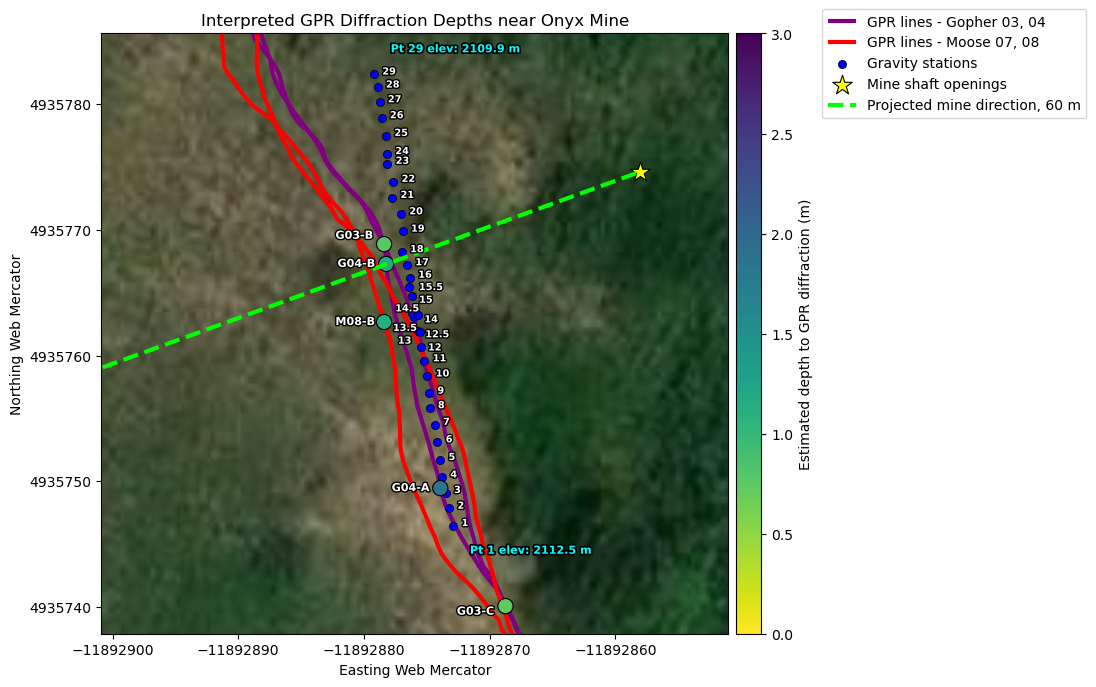

In [10]:
figsize = (10, 20)
buffer = -5

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-B": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_3857,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_3857.columns."
)

elevation_col = find_col(
    gravity_3857,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_3857.columns."
)

poi_name_col = find_col(
    poi_3857,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_3857.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_3857 = gravity_3857.copy()

gravity_3857["station_num_clean"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_3857[
    poi_3857[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_3857[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_m * np.sin(azimuth_rad)
dy = mine_projection_length_m * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_3857.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_3857.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7*buffer, xmax + -1.4*buffer)
ax.set_ylim(ymin - 1.6 * buffer, ymax + 4 * buffer)


# ============================================================
# Basemap
# ============================================================

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Plot GPR diffraction anomalies with fixed colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_3857.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_3857[
    gravity_3857["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_3857.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.15, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

plt.show()

In [11]:
lidar_path = "../../data/LiDAR/LiDAR_2026-06-05T15_32_32.740Z/"

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T15_32_32.740Z")

lidar_files = sorted(lidar_folder.glob("*.tif"))

print("LiDAR files found:")
for f in lidar_files:
    print(f)

LiDAR files found:


In [14]:

if len(lidar_files) == 0:
    lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
    lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError("No .tif LiDAR files found. Check your lidar_folder path.")

print(f"Found {len(lidar_files)} LiDAR files:")
for f in lidar_files:
    print(f)

Found 21 LiDAR files:
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26261415.tif
..\..\data\LiDAR\LiDAR_2026-06-05

In [15]:
for fp in lidar_files:
    with rasterio.open(fp) as src:
        print("\nFILE:", fp.name)
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Nodata:", src.nodata)
        print("Units maybe:", src.crs.linear_units if src.crs else "unknown")


FILE: LD26171415.tif
CRS: PROJCS["NAD83(2011) / Colorado North (ftUS)",GEOGCS["NAD83(2011)",DATUM["unnamed",SPHEROID["unnamed",6378137,298.257222101004],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",39.3333333333333],PARAMETER["central_meridian",-105.5],PARAMETER["standard_parallel_1",39.7166666666667],PARAMETER["standard_parallel_2",40.7833333333333],PARAMETER["false_easting",3000000.00031608],PARAMETER["false_northing",999999.999996],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: BoundingBox(left=2617000.0, bottom=1415000.0, right=2620000.0, top=1418000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26171418.tif
CRS: PROJCS["NAD83(2011) / Colorado North (ftUS)",GEOGCS["NAD83(2011)",DATUM["unnamed",SPHEROID["unnamed",6378137,298.257222101004],AUTHORITY["EPSG","1116"]],PRI

LiDAR files being used:
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26261415.tif
..\..\data\LiDAR\LiDAR_2026-06-

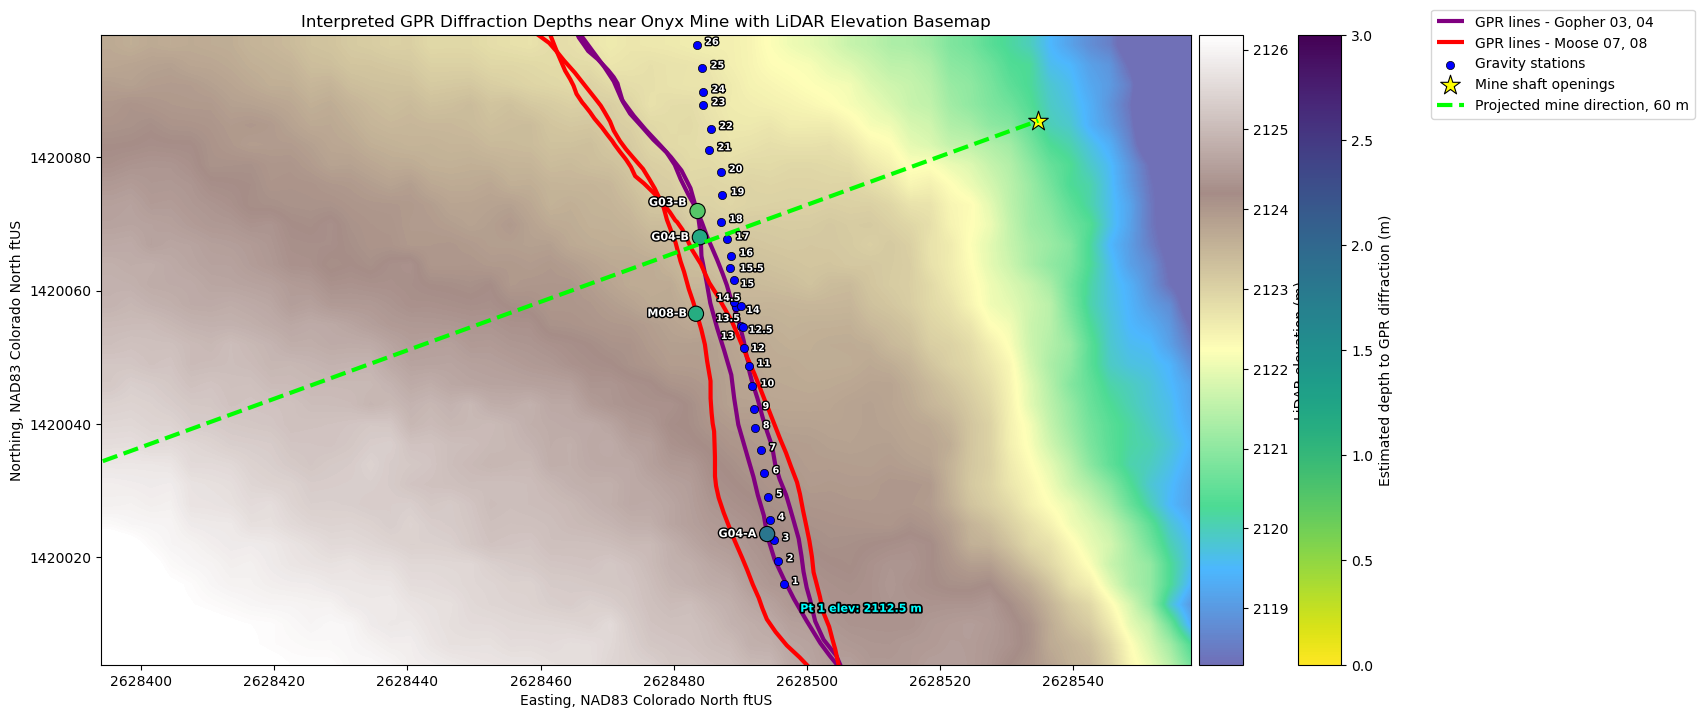

In [22]:
figsize = (20, 35)

# Your LiDAR CRS is Colorado North ftUS, so map coordinates are feet.
# These values are written in meters and converted below.
buffer_m = -5

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

lidar_alpha = 0.70
lidar_cmap = "terrain"

# LiDAR horizontal CRS is ftUS.
# Elevation values are probably also feet unless metadata says otherwise.
lidar_z_units = "ft"   # use "ft", "in", or "m"

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-A": (10, 0, "left", "center"),
    "M08-A": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219
buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nPlotting all survey data in LiDAR CRS:")
print(lidar_crs)


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_plot.columns."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_plot.columns."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7 * buffer, xmax + -1.4 * buffer)
ax.set_ylim(ymin - 1.8 * buffer, ymax + 4 * buffer)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()


# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax),
        masked=True
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)
lidar_elev = np.ma.filled(lidar_elev, np.nan)

# Convert LiDAR elevation values to meters
lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles still do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbars
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")

cax_depth = divider.append_axes(
    "right",
    size="4%",
    pad=0.55
)


# ============================================================
# Plot GPR diffraction anomalies
# ============================================================

anomaly_plot.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax_depth,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_plot[
    gravity_plot["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_plot.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine with LiDAR Elevation Basemap")
ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.22, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

plt.show()

LiDAR files being used:
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26261415.tif
..\..\data\LiDAR\LiDAR_2026-06-

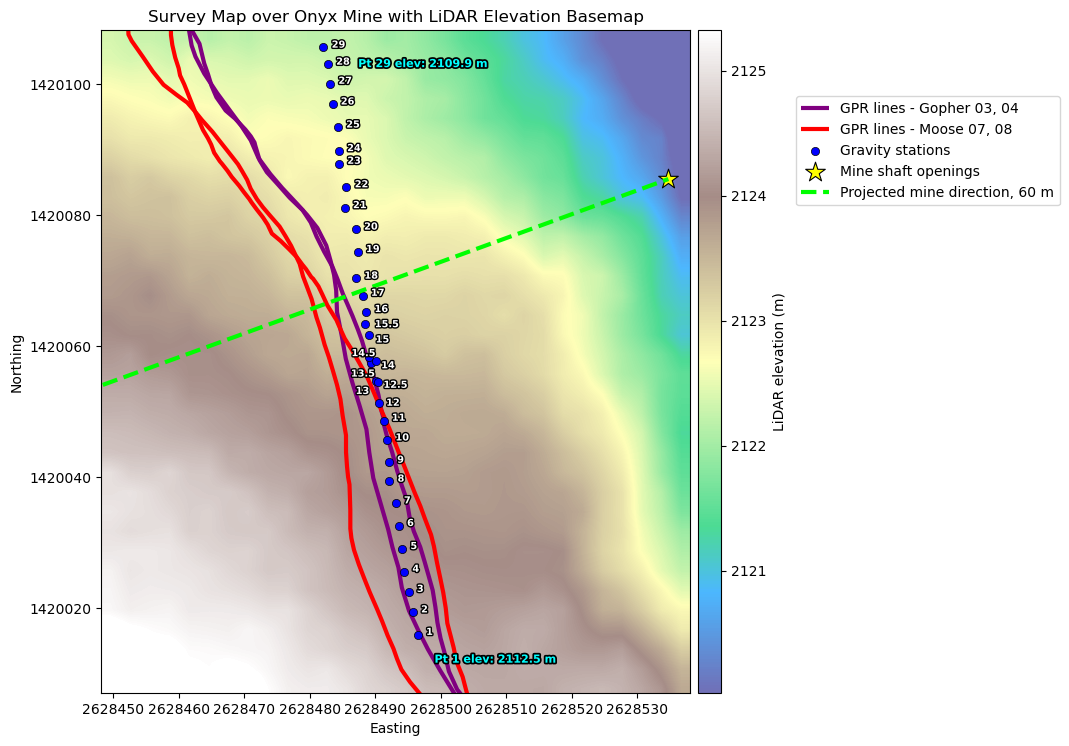

In [42]:
# ============================================================
# Adjustable settings
# ============================================================

figsize = (10, 11)

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

lidar_alpha = 0.70
lidar_cmap = "terrain"

# LiDAR horizontal CRS is ftUS.
# Elevation values are probably also feet unless metadata says otherwise.
lidar_z_units = "ft"   # use "ft", "in", or "m"

# Manual map padding in meters
pad_west_m  = -30
pad_east_m  = 1
pad_south_m = -10
pad_north_m = -17  # increased north coverage

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (25, -12, "left", "center"),   # moved down so it is not cut off
}

# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

pad_west  = pad_west_m  * ftus_per_m
pad_east  = pad_east_m  * ftus_per_m
pad_south = pad_south_m * ftus_per_m
pad_north = pad_north_m * ftus_per_m

mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nPlotting all survey data in LiDAR CRS:")
print(lidar_crs)


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_plot.columns."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_plot.columns."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - pad_west, xmax + pad_east)
ax.set_ylim(ymin - pad_south, ymax + pad_north)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()


# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax),
        masked=True
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)
lidar_elev = np.ma.filled(lidar_elev, np.nan)

# Convert LiDAR elevation values to meters
lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles still do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")



# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_plot[
    gravity_plot["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "right", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )



# ============================================================
# Final formatting
# ============================================================

ax.set_title("Survey Map over Onyx Mine with LiDAR Elevation Basemap")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.18, .90),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

#plt.savefig("onyx_mine_lidar_basemap.png", dpi=300, bbox_inches="tight")
plt.show()

LiDAR files being used:
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26171427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26201427.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231415.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231418.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231421.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26231424.tif
..\..\data\LiDAR\LiDAR_2026-06-05T19_40_33.076Z\LD26261415.tif
..\..\data\LiDAR\LiDAR_2026-06-

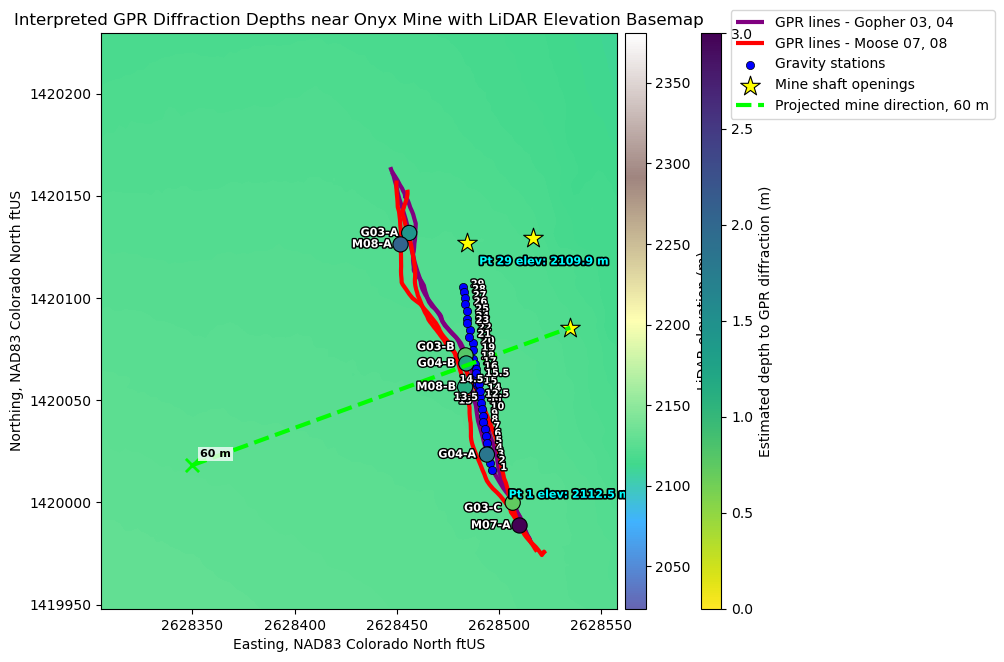

In [18]:
figsize = (10, 20)

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")

# LiDAR horizontal map units are US survey feet.
# These map-display buffers are entered in meters and converted to ftUS.
buffer_m = 5

# LiDAR elevation values are probably feet.
# Use "ft", "in", or "m".
lidar_z_units = "ft"

lidar_alpha = 0.75
lidar_cmap = "terrain"

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

zoom_vmin = 0.0
zoom_vmax = 3.0

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8


# ============================================================
# Label offsets
# ============================================================

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-A": (10, 0, "left", "center"),
    "M08-A": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219
buffer = buffer_m * ftus_per_m
mine_projection_length_ftus = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)
        if value.is_integer():
            return str(int(value)), int(value)
        return str(value).rstrip("0").rstrip("."), value
    except Exception:
        return str(value), value


def print_bounds(name, gdf):
    b = gdf.total_bounds
    print(f"{name} bounds:")
    print(f"  xmin={b[0]:.2f}, ymin={b[1]:.2f}, xmax={b[2]:.2f}, ymax={b[3]:.2f}")


# ============================================================
# Load LiDAR files and native LiDAR CRS
# ============================================================

lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No .tif LiDAR files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nLiDAR CRS:")
print(lidar_crs)


# ============================================================
# Merge full LiDAR tile set first
# No crop yet. This prevents the empty-crop error.
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(srcs, masked=True)
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)
lidar_elev = np.ma.filled(lidar_elev, np.nan)

lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError("Merged LiDAR raster is all NaN. Check the raster values/nodata.")

lidar_left, lidar_bottom, lidar_right, lidar_top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

print("\nMerged LiDAR bounds:")
print(f"  xmin={lidar_left:.2f}, ymin={lidar_bottom:.2f}, xmax={lidar_right:.2f}, ymax={lidar_top:.2f}")


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Print survey bounds
# These should be close to the LiDAR bounds above.
# ============================================================

print("\nSurvey bounds after reprojection to LiDAR CRS:")
print_bounds("gravity_plot", gravity_plot)
print_bounds("poi_plot", poi_plot)
print_bounds("selected_gpr_lines_plot", selected_gpr_lines_plot)
print_bounds("anomaly_plot", anomaly_plot)


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column."
)

gravity_plot = gravity_plot.copy()
gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_ftus * np.sin(azimuth_rad)
dy = mine_projection_length_ftus * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=lidar_crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=lidar_crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7 * buffer, xmax + 1.4 * buffer)
ax.set_ylim(ymin - 1.6 * buffer, ymax + 4.0 * buffer)


# ============================================================
# Plot LiDAR elevation basemap
# ============================================================

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[lidar_left, lidar_right, lidar_bottom, lidar_top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations and mine openings
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
        zorder=10
    )


# ============================================================
# Colorbars
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes("right", size="4%", pad=0.08)
cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")

cax_depth = divider.append_axes("right", size="4%", pad=0.55)


# ============================================================
# Plot GPR diffraction anomalies
# ============================================================

anomaly_plot.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax_depth,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[pe.withStroke(linewidth=2, foreground="black")]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_plot[
    gravity_plot["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[pe.withStroke(linewidth=2.5, foreground="black")]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_plot.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[pe.withStroke(linewidth=2, foreground="black")]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine with LiDAR Elevation Basemap")
ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.22, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

plt.show()

In [ ]:

# Put all survey layers into WGS84 lat/lon
all_wgs84 = pd.concat([
    gravity_gdf.to_crs("EPSG:4326")[["geometry"]],
    poi_gdf.to_crs("EPSG:4326")[["geometry"]],
    gpr_lines_gdf.to_crs("EPSG:4326")[["geometry"]],
    anomaly_gdf.to_crs("EPSG:4326")[["geometry"]]
])

lon_min, lat_min, lon_max, lat_max = all_wgs84.total_bounds

# Buffer around survey area.
# 0.003 degrees is roughly a few hundred meters here.
deg_buffer = 0.003

lon_min -= deg_buffer
lon_max += deg_buffer
lat_min -= deg_buffer
lat_max += deg_buffer

print("TessaDEM request bounds:")
print(f"south = {lat_min}")
print(f"west  = {lon_min}")
print(f"north = {lat_max}")
print(f"east  = {lon_max}")

In [ ]:

TESSADEM_API_KEY = "d6cd0d23b66f54671fdd2b4d96e2eed7b79f71e6"

dem_out_folder = Path("../../data/DEM")
dem_out_folder.mkdir(parents=True, exist_ok=True)

dem_path = dem_out_folder / "tessadem_onyx_area.tif"
error_path = dem_out_folder / "tessadem_error_response.txt"

# Delete old invalid downloads
if dem_path.exists():
    dem_path.unlink()

url = "https://tessadem.com/api/elevation"

params = {
    "key": TESSADEM_API_KEY,
    "mode": "area",
    "format": "geotiff",
    "units": "meters",
    "south": lat_min,
    "west": lon_min,
    "north": lat_max,
    "east": lon_max,
}

response = requests.get(url, params=params, timeout=120)

print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Response size:", len(response.content), "bytes")
print("Request URL:")
print(response.url)

if response.status_code != 200:
    error_path.write_bytes(response.content)

    print("\nAPI error response:")
    print(response.text[:2000])

    try:
        print("\nParsed JSON error:")
        print(json.dumps(response.json(), indent=4))
    except Exception:
        pass

    raise RuntimeError(f"TessaDEM request failed. Error saved to: {error_path}")

is_tiff = (
    response.content.startswith(b"II*\x00") or
    response.content.startswith(b"MM\x00*")
)

if not is_tiff:
    error_path.write_bytes(response.content)

    print("\nResponse was not a GeoTIFF. First 1000 characters:")
    print(response.text[:1000])

    raise RuntimeError(f"TessaDEM response was not a GeoTIFF. Saved to: {error_path}")

dem_path.write_bytes(response.content)

print("\nSaved valid TessaDEM GeoTIFF to:")
print(dem_path)

In [ ]:
# ============================================================
# Download TessaDEM area GeoTIFF from API
# Correct TessaDEM syntax:
# locations = "southwest_lat,southwest_lon|northeast_lat,northeast_lon"
# ============================================================

import requests
from pathlib import Path
import json

TESSADEM_API_KEY = "d6cd0d23b66f54671fdd2b4d96e2eed7b79f71e6"

dem_out_folder = Path("../../data/DEM")
dem_out_folder.mkdir(parents=True, exist_ok=True)

dem_path = dem_out_folder / "tessadem_onyx_area.tif"
error_path = dem_out_folder / "tessadem_error_response.txt"

# Delete old bad file if present
if dem_path.exists():
    dem_path.unlink()

url = "https://tessadem.com/api/elevation"

# Southwest and northeast corners of the requested rectangle
locations = f"{lat_min},{lon_min}|{lat_max},{lon_max}"

# TessaDEM max area request size is rows * columns <= 16,384.
# 128 x 128 = 16,384.
rows = 128
columns = 128

params = {
    "key": TESSADEM_API_KEY,
    "mode": "area",
    "rows": rows,
    "columns": columns,
    "locations": locations,
    "format": "geotiff",
    "unit": "meters",
}

response = requests.get(url, params=params, timeout=120)

print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Response size:", len(response.content), "bytes")
print("Request URL:")
print(response.url)

if response.status_code != 200:
    error_path.write_bytes(response.content)

    print("\nAPI error response:")
    print(response.text[:2000])

    try:
        print("\nParsed JSON error:")
        print(json.dumps(response.json(), indent=4))
    except Exception:
        pass

    raise RuntimeError(f"TessaDEM request failed. Error saved to: {error_path}")

is_tiff = (
    response.content.startswith(b"II*\x00") or
    response.content.startswith(b"MM\x00*")
)

if not is_tiff:
    error_path.write_bytes(response.content)

    print("\nResponse was not a GeoTIFF. First 1000 characters:")
    print(response.text[:1000])

    raise RuntimeError(f"TessaDEM response was not a GeoTIFF. Saved to: {error_path}")

dem_path.write_bytes(response.content)

print("\nSaved valid TessaDEM GeoTIFF to:")
print(dem_path)

In [ ]:
# ============================================================
# Download smaller TessaDEM area GeoTIFF from API
# ============================================================

import requests
from pathlib import Path
import json

TESSADEM_API_KEY = "PASTE_YOUR_REAL_KEY_HERE"

dem_out_folder = Path("../../data/DEM")
dem_out_folder.mkdir(parents=True, exist_ok=True)

dem_path = dem_out_folder / "tessadem_onyx_area.tif"
error_path = dem_out_folder / "tessadem_error_response.txt"

if dem_path.exists():
    dem_path.unlink()

url = "https://tessadem.com/api/elevation"

locations = f"{lat_min},{lon_min}|{lat_max},{lon_max}"

# Smaller request to reduce API cost
rows = 32
columns = 32

params = {
    "key": TESSADEM_API_KEY,
    "mode": "area",
    "rows": rows,
    "columns": columns,
    "locations": locations,
    "format": "geotiff",
    "unit": "meters",
}

response = requests.get(url, params=params, timeout=120)

print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Response size:", len(response.content), "bytes")
print("Request URL:")
print(response.url)

if response.status_code != 200:
    error_path.write_bytes(response.content)

    print("\nAPI error response:")
    print(response.text[:2000])

    try:
        print("\nParsed JSON error:")
        print(json.dumps(response.json(), indent=4))
    except Exception:
        pass

    raise RuntimeError(f"TessaDEM request failed. Error saved to: {error_path}")

is_tiff = (
    response.content.startswith(b"II*\x00") or
    response.content.startswith(b"MM\x00*")
)

if not is_tiff:
    error_path.write_bytes(response.content)

    print("\nResponse was not a GeoTIFF. First 1000 characters:")
    print(response.text[:1000])

    raise RuntimeError(f"TessaDEM response was not a GeoTIFF. Saved to: {error_path}")

dem_path.write_bytes(response.content)

print("\nSaved valid TessaDEM GeoTIFF to:")
print(dem_path)

In [ ]:

contour_path = "../../../../Downloads/Steamboat_1ftcontour/Steamboat_Contour2.shp"  # change this path
contours = gpd.read_file(contour_path)

print("Contour CRS:", contours.crs)
print("Contour bounds:", contours.total_bounds)
print("Columns:", contours.columns)
print(contours[["ELEVATION"]].describe())

In [ ]:
contours_plot = contours.to_crs(gravity_plot.crs)

contours_near_site = contours_plot.cx[
    xmin - 100:xmax + 100,
    ymin - 100:ymax + 100
].copy()

contours_near_site["elevation_m"] = contours_near_site["ELEVATION"] * 0.3048

contours_near_site.plot(
    ax=ax,
    column="elevation_m",
    cmap="terrain",
    linewidth=0.6,
    alpha=0.65,
    legend=True,
    zorder=1
)

In [ ]:
# ============================================================
# Plot survey map with contour elevation basemap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point, LineString
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe


# ============================================================
# Adjustable settings
# ============================================================

figsize = (10, 15)

# Change this to where the shapefile is on your computer/repo
contour_path = Path("../../../../Downloads/Steamboat_1ftcontour/Steamboat_Contour2.shp")

# If the file is in the same folder as your notebook, use this instead:
# contour_path = Path("Steamboat_Contour2.shp")

buffer_m = 5

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

zoom_vmin = 0.0
zoom_vmax = 3.0

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

contour_linewidth = 0.7
contour_alpha = 0.75
contour_cmap = "terrain"

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-A": (10, 0, "left", "center"),
    "M08-A": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load contour shapefile
# ============================================================

if not contour_path.exists():
    raise FileNotFoundError(
        f"Could not find contour shapefile at:\n{contour_path}\n\n"
        "Move Steamboat_Contour2.shp and its .dbf/.shx/.prj files into that folder, "
        "or change contour_path."
    )

contours = gpd.read_file(contour_path)

print("Contour CRS:")
print(contours.crs)

print("\nContour columns:")
print(contours.columns)

print("\nContour bounds:")
print(contours.total_bounds)

if contours.crs is None:
    raise ValueError("Contour file has no CRS. Check that the .prj file is in the same folder.")


# ============================================================
# Use contour CRS as plot CRS
# ============================================================

plot_crs = contours.crs

gravity_plot = gravity_gdf.to_crs(plot_crs)
poi_plot = poi_gdf.to_crs(plot_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(plot_crs)
gpr_points_plot = gpr_points_gdf.to_crs(plot_crs)
anomaly_plot = anomaly_gdf.to_crs(plot_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column."
)

contour_elev_col = find_col(
    contours,
    ["ELEVATION", "Elevation", "elevation", "ELEV", "Elev", "elev"],
    "Could not find contour elevation column."
)


# ============================================================
# Prep elevation values
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)

contours = contours.copy()
contours[contour_elev_col] = pd.to_numeric(
    contours[contour_elev_col],
    errors="coerce"
)

# Contour elevations are in feet. Convert to meters.
contours["elevation_m"] = contours[contour_elev_col] * 0.3048


# ============================================================
# Unit conversion for map distances
# Contour CRS is ftUS, so convert meter distances to ftUS.
# ============================================================

ftus_per_m = 1 / 0.304800609601219

buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=plot_crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=plot_crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

plot_xmin = xmin - 2.7 * buffer
plot_xmax = xmax + 1.4 * buffer
plot_ymin = ymin - 1.6 * buffer
plot_ymax = ymax + 4.0 * buffer


# ============================================================
# Clip contours to nearby map area
# ============================================================

contours_near_site = contours.cx[
    plot_xmin - 100:plot_xmax + 100,
    plot_ymin - 100:plot_ymax + 100
].copy()

if contours_near_site.empty:
    raise ValueError(
        "No contours found near the plotted survey area. "
        "Check CRS or shapefile coverage."
    )

print("\nContours near site:", len(contours_near_site))
print("Elevation range near site:")
print(contours_near_site["elevation_m"].describe())


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(plot_xmin, plot_xmax)
ax.set_ylim(plot_ymin, plot_ymax)


# ============================================================
# Plot contour elevation basemap behind everything
# ============================================================

contours_near_site.plot(
    ax=ax,
    column="elevation_m",
    cmap=contour_cmap,
    linewidth=contour_linewidth,
    alpha=contour_alpha,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbars
# ============================================================

divider = make_axes_locatable(ax)

# Contour elevation colorbar
cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

sm = plt.cm.ScalarMappable(
    cmap=contour_cmap,
    norm=plt.Normalize(
        vmin=contours_near_site["elevation_m"].min(),
        vmax=contours_near_site["elevation_m"].max()
    )
)

sm.set_array([])

cbar_elev = fig.colorbar(sm, cax=cax_elev)
cbar_elev.set_label("Contour elevation (m)")

# GPR depth colorbar
cax_depth = divider.append_axes(
    "right",
    size="4%",
    pad=0.55
)


# ============================================================
# Plot GPR diffraction anomalies
# ============================================================

anomaly_plot.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax_depth,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_plot[
    gravity_plot["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_plot.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine with Contour Elevation Basemap")
ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.22, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

plt.show()